<a href="https://colab.research.google.com/github/Marion-Moraa/African-recipe-platform/blob/main/NYC_Bike_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NYC Bike Data Analysis

In [1]:
#importing module
import pandas as pd
import matplotlib.pyplot as plt

#Data Loading

In [3]:
#Load data
data = pd.read_excel("/content/New York Citi Bikes Raw Data unclean.xlsx")
#display first five rows of dataset
data.head()

,Start Time,Stop Time,Start Station ID,Start Station Name,End Station ID,End Station Name,Bike ID,User Type,Birth Year,Age,Age Groups,Trip Duration,Trip_Duration_in_min,Month,Season,Temperature,Weekday
0,2017-01-01 00:38:00,2017-01-01 01:03:00,3194,McGinley Square,3271,Danforth Light Rail,24668,Subscriber,1961,60,55-64,1513,25,1,Winter,10,Sunday
1,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday
2,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday
3,2017-01-01 01:56:00,2017-01-01 02:00:00,3186,Grove St PATH,3270,Jersey & 6th St,24604,Subscriber,1970,51,45-54,258,4,1,Winter,10,Sunday
4,2017-01-01 02:12:00,2017-01-01 02:23:00,3270,Jersey & 6th St,3206,Hilltop,24641,Subscriber,1978,43,35-44,663,11,1,Winter,10,Sunday


#Data Cleaning

In [4]:
#Remove duplicates
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [5]:
#Check missing values
data.isnull().sum()

,0
Start Time,0
Stop Time,0
Start Station ID,0
Start Station Name,0
End Station ID,0
End Station Name,1
Bike ID,0
User Type,0
Birth Year,0
Age,0


In [6]:
#Count total empty rows
data.isnull().all(axis=1).sum()

np.int64(0)

In [7]:
#Remove empty rows
data = data.dropna()

In [8]:
#Check columns
data.columns

Index(['Start Time', 'Stop Time', 'Start Station ID', 'Start Station Name',
       'End Station ID', 'End Station Name', 'Bike ID', 'User Type',
       'Birth Year', 'Age', 'Age Groups', 'Trip Duration',
       'Trip_Duration_in_min', 'Month', 'Season', 'Temperature', 'Weekday'],
      dtype='object')

In [9]:
#Check column names and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16844 entries, 0 to 20399
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Start Time            16844 non-null  datetime64[ns]
 1   Stop Time             16844 non-null  datetime64[ns]
 2   Start Station ID      16844 non-null  int64         
 3   Start Station Name    16844 non-null  object        
 4   End Station ID        16844 non-null  int64         
 5   End Station Name      16844 non-null  object        
 6   Bike ID               16844 non-null  int64         
 7   User Type             16844 non-null  object        
 8   Birth Year            16844 non-null  int64         
 9   Age                   16844 non-null  int64         
 10  Age Groups            16844 non-null  object        
 11  Trip Duration         16844 non-null  int64         
 12  Trip_Duration_in_min  16844 non-null  int64         
 13  Month                

In [10]:
#Statistics
data.describe()

,Start Time,Stop Time,Start Station ID,End Station ID,Bike ID,Birth Year,Age,Trip Duration,Trip_Duration_in_min,Month,Temperature
count,16844,16844,16844.000000,16844.000000,16844.000000,16844.000000,16844.000000,16844.000000,16844.000000,16844.000000,16844.000000
mean,2017-02-19 21:12:05.218475520,2017-02-19 21:21:40.693422080,3215.886072,3211.575576,25292.898599,1979.304263,41.695737,574.706780,9.578307,2.151686,14.754096
min,2017-01-01 00:38:00,2017-01-01 01:03:00,3183.000000,152.000000,15084.000000,1931.000000,22.000000,61.000000,1.000000,1.000000,9.000000
25%,2017-01-29 18:06:15,2017-01-29 18:09:30,3186.000000,3186.000000,24523.000000,1974.000000,35.000000,220.000000,4.000000,1.000000,13.000000
50%,2017-02-23 18:05:00,2017-02-23 18:13:00,3203.000000,3202.000000,24678.000000,1982.000000,39.000000,312.000000,5.000000,2.000000,15.000000
75%,2017-03-09 18:24:00,2017-03-09 18:30:15,3267.000000,3217.750000,26219.000000,1986.000000,47.000000,515.000000,9.000000,3.000000,16.000000
max,2017-03-31 23:20:00,2017-03-31 23:30:00,3281.000000,3442.000000,29296.000000,1999.000000,90.000000,390893.000000,6515.000000,3.000000,19.000000
std,NaN,NaN,34.593994,80.103895,971.139271,10.051886,10.051886,4306.726768,71.778274,0.822899,2.388317


In [11]:
#Filter row in Trip_Duration_in_min with 6515
data = data[data['Trip_Duration_in_min'] != 6515]

In [12]:
#Inspect Trip_Duration_in_min
data['Trip_Duration_in_min'].describe()

,Trip_Duration_in_min
count,16843.000000
mean,9.192068
std,51.375882
min,1.000000
25%,4.000000
50%,5.000000
75%,9.000000
max,3693.000000


The dataset initially contained some extreme values in Trip_Duration_in_min, such as 6515 minutes, which are likely data entry errors or unusually long trips. These outliers were removed to ensure the analysis reflects typical ride durations. After cleaning, the average trip duration is  9.1920 minutes, the median is 5 minutes, the minimum is 1 minute, and the maximum is 3693 minutes. This gives a more accurate representation of typical Citi Bike rides.

In [13]:
#Reset index
data = data.reset_index(drop=True)


The dataset was cleaned to improve data quality before analysis. Duplicate records were removed using the drop_duplicates() function. Missing values were identified using isnull() and handled by removing rows with null or empty values using the dropna() function to ensure data consistency.

#Feature Engineering
Create needed columns


In [14]:
#Convert Start Time to datetime
data['Start Time'] = pd.to_datetime(data['Start Time'])

In [15]:
#Create Day of Week
data['day_of_week'] = data['Start Time'].dt.day_name()
data.head()

,Start Time,Stop Time,Start Station ID,Start Station Name,End Station ID,End Station Name,Bike ID,User Type,Birth Year,Age,Age Groups,Trip Duration,Trip_Duration_in_min,Month,Season,Temperature,Weekday,day_of_week
0,2017-01-01 00:38:00,2017-01-01 01:03:00,3194,McGinley Square,3271,Danforth Light Rail,24668,Subscriber,1961,60,55-64,1513,25,1,Winter,10,Sunday,Sunday
1,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday,Sunday
2,2017-01-01 01:56:00,2017-01-01 02:00:00,3186,Grove St PATH,3270,Jersey & 6th St,24604,Subscriber,1970,51,45-54,258,4,1,Winter,10,Sunday,Sunday
3,2017-01-01 02:12:00,2017-01-01 02:23:00,3270,Jersey & 6th St,3206,Hilltop,24641,Subscriber,1978,43,35-44,663,11,1,Winter,10,Sunday,Sunday
4,2017-01-01 02:22:00,2017-01-01 02:31:00,3212,Christ Hospital,3225,Baldwin at Montgomery,24520,Subscriber,1987,34,25-34,535,9,1,Winter,10,Sunday,Sunday


In [16]:
#Create Hour
data['hour'] = data['Start Time'].dt.hour
data.head()

,Start Time,Stop Time,Start Station ID,Start Station Name,End Station ID,End Station Name,Bike ID,User Type,Birth Year,Age,Age Groups,Trip Duration,Trip_Duration_in_min,Month,Season,Temperature,Weekday,day_of_week,hour
0,2017-01-01 00:38:00,2017-01-01 01:03:00,3194,McGinley Square,3271,Danforth Light Rail,24668,Subscriber,1961,60,55-64,1513,25,1,Winter,10,Sunday,Sunday,0
1,2017-01-01 01:47:00,2017-01-01 01:58:00,3183,Exchange Place,3203,Hamilton Park,26167,Subscriber,1993,28,25-34,639,11,1,Winter,10,Sunday,Sunday,1
2,2017-01-01 01:56:00,2017-01-01 02:00:00,3186,Grove St PATH,3270,Jersey & 6th St,24604,Subscriber,1970,51,45-54,258,4,1,Winter,10,Sunday,Sunday,1
3,2017-01-01 02:12:00,2017-01-01 02:23:00,3270,Jersey & 6th St,3206,Hilltop,24641,Subscriber,1978,43,35-44,663,11,1,Winter,10,Sunday,Sunday,2
4,2017-01-01 02:22:00,2017-01-01 02:31:00,3212,Christ Hospital,3225,Baldwin at Montgomery,24520,Subscriber,1987,34,25-34,535,9,1,Winter,10,Sunday,Sunday,2


In [17]:
#Check needed columns
data[['day_of_week', 'hour', 'Age', 'Age Groups']].head()

,day_of_week,hour,Age,Age Groups
0,Sunday,0,60,55-64
1,Sunday,1,28,25-34
2,Sunday,1,51,45-54
3,Sunday,2,43,35-44
4,Sunday,2,34,25-34


New columns such as day_of_week and hour were created from existing variables to enable meaningful analysis and answer the research questions.

#Analysis
##1.Most popular pick-up locations across the city for Citi Bike rental services.

In [18]:
#Q1: Most popular stations
data['Start Station Name'].value_counts().head()

,count
Start Station Name,
Grove St PATH,2115
Exchange Place,1224
Sip Ave,1084
Hamilton Park,1069
Morris Canal,710


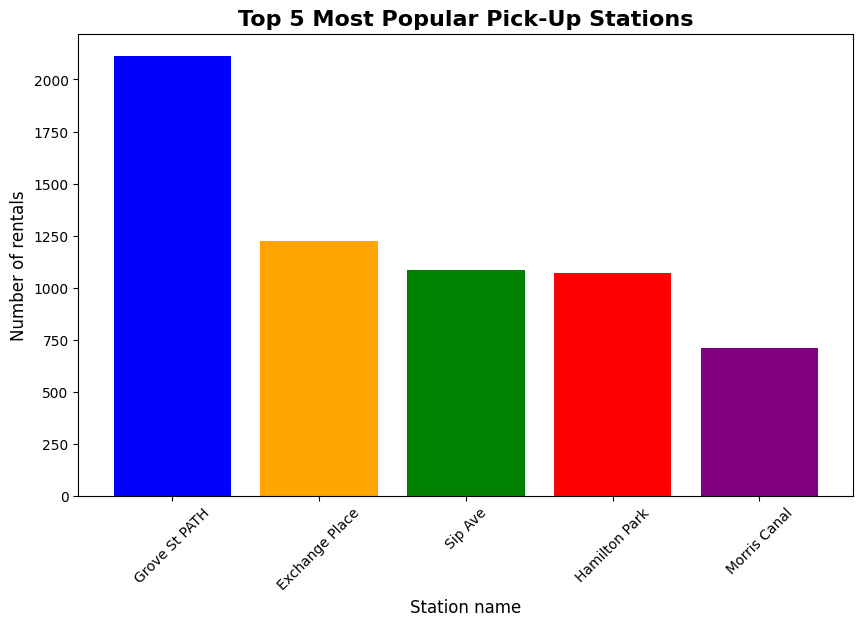

In [31]:
#Top 5 stations
top_stations = data['Start Station Name'].value_counts().head()

#Create figure
plt.figure(figsize=(10,6))

#Different bar colors
colors=['blue', 'orange', 'green', 'red', 'purple']

#Create Bar chart
plt.bar(top_stations.index, top_stations.values, color=colors)

#Titles and labels
plt.xlabel('Station name', fontsize=12)
plt.ylabel('Number of rentals', fontsize=12)
plt.title('Top 5 Most Popular Pick-Up Stations', fontsize=16, fontweight='bold')
plt.xticks(rotation=45) #Prevents labels overlapping

#Display Chart
plt.show()






Insight:

Grove St PATH recorded the highest number of rentals, indicating high commuter activity in that area.

##2.How does the average trip duration vary across different age groups?

In [35]:
#Q2: Average duration by age group
avg_duration = data.groupby('Age Groups')['Trip_Duration_in_min'].mean()
avg_duration

,Trip_Duration_in_min
Age Groups,
18-24,11.981481
25-34,9.180410
35-44,9.375991
45-54,8.215607
55-64,9.393918
65-74,7.417886
75+,48.872727


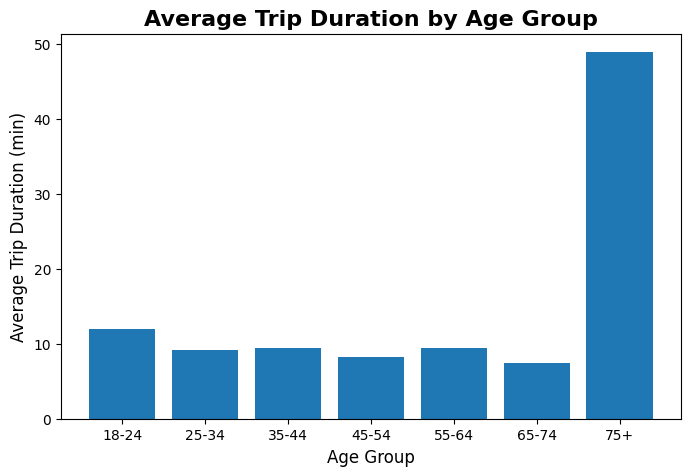

In [37]:
plt.figure(figsize=(8,5))
plt.bar(avg_duration.index, avg_duration.values)

#Title and labels
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Average Trip Duration (min)', fontsize=12)
plt.title('Average Trip Duration by Age Group', fontsize=16, fontweight='bold')

#Display Chart
plt.show()


Most age groups have 7-12 min trips; 18-24 slightly higher (12min); 75+ is an outlier (49 min).

Older age groups recorded longer average trip durarions, suggesting they tend to use bikes for extended rides compared to younger riders.

##3.Which age group rents the most bikes?

In [38]:
#Q3: Most active age group
most_bikes = data['Age Groups'].value_counts()
most_bikes

,count
Age Groups,
35-44,7697
25-34,4002
45-54,2973
55-64,1447
65-74,615
75+,55
18-24,54


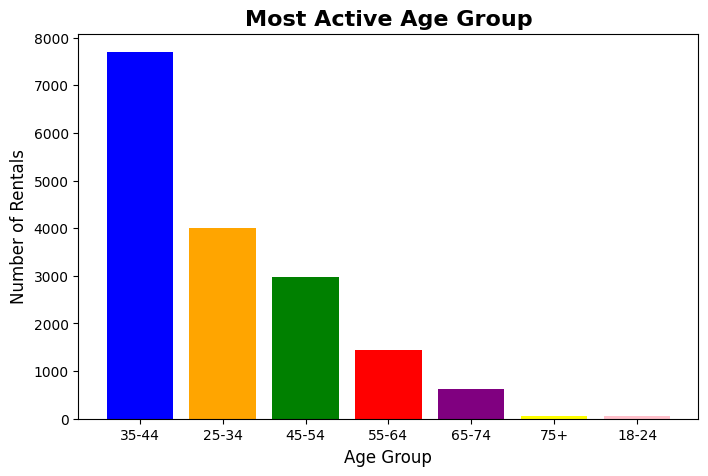

In [39]:
#Create figure
plt.figure(figsize=(8,5))
colors=['blue', 'orange', 'green', 'red', 'purple', 'yellow', 'pink']

#Create bar chart
plt.bar(most_bikes.index, most_bikes.values, color=colors)

#Title and labels
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Rentals', fontsize=12)
plt.title('Most Active Age Group', fontsize=16, fontweight='bold')

#Display Chart
plt.show()

Age group 35-44 rents the most bikes.

##4.How does bike rental vary across the two user groups (one-time users vs long-term subscribers) on different days of the week?

In [21]:
#Q4: User type vs day
pd.crosstab(data['day_of_week'], data['User Type'])

User Type,One-time user,Subscriber
day_of_week,,
Friday,26,2422
Monday,52,2474
Saturday,93,1497
Sunday,64,1501
Thursday,19,2934
Tuesday,24,2436
Wednesday,39,3262


Subscribers account for most bike rentals every day, with the highest midweek activity on Wednesday. One-time users mostly rent bikes on weekends, peaking on Saturday and Sunday.

##5.Does user age impact the average bike trip duration?

In [22]:
#Q5: Age vs duration
data.groupby('Age Groups') ['Trip Duration'].mean()

,Trip Duration
Age Groups,
18-24,721.685185
25-34,551.302599
35-44,562.270365
45-54,493.015136
55-64,563.563234
65-74,445.216260
75+,2934.018182


Average trip duration is fairly similar across most age groups, ranging from about 445 to 722 minutes. The 75+ group is an outlier with an unusually high average, likely caused by a very small number of long trips. Overall, user age has some effect on trip duration, but most age groups ride similar lengths.